In [1]:
import pandas as pd
import numpy as np
import calendar
import sys
import os
import re
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer



sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.load_data import load_and_preprocess_data

In [2]:
# Load the data
file_path = 'data/processed/NEISS_Supplement_91355_Samples.xlsx'
print(f"Loading classified data from {file_path}...")
df = pd.read_excel(file_path, sheet_name='sample_eval', dtype=str)
print(f"Loaded {len(df)} rows.")

Loading classified data from data/processed/NEISS_Supplement_91355_Samples.xlsx...
Loaded 91355 rows.


# Data Preprocessing

In [3]:
# Convert weights to numeric
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')

# Filter dataset to analyze ONLY Vitamin exposures (Denominator Problem)
df = df[df['LLM_Label'].astype(int) == 1].copy()

# Convert Treatment_Date to actual datetime objects
df['Treatment_Date'] = pd.to_datetime(df['Treatment_Date'], errors='coerce')
df['Year'] = df['Treatment_Date'].dt.year
df['Month'] = df['Treatment_Date'].dt.month
df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)

# Drop rows with invalid dates
df = df.dropna(subset=['Year', 'Month'])

# Ensure 'Age' column is numeric, converting non-numeric values to NaN (Not a Number)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age_Years'] = np.where(df['Age'] >= 200, (df['Age'] - 200) / 12, df['Age'])

# Age Grouping (<1, 1, 2, 3, 4+)
df['Age_Group'] = np.where(df['Age_Years'] < 1, '<1',
                      np.where(df['Age_Years'] < 2, '1',
                      np.where(df['Age_Years'] < 3, '2',
                      np.where(df['Age_Years'] < 4, '3', '4+'))))

# Mapping standard NEISS codes for readability in plots
sex_map = {'1': 'Male', '2': 'Female', '0': 'Unknown'}
race_map = {'1': 'White', '2': 'Black', '3': 'Other', '0': 'Unknown', np.nan: 'Unknown'}
disp_map = {'1': 'Treated/Released', '2': 'Transferred', '4': 'Admitted', '5': 'Observation', '6': 'Left AMA', '8': 'Fatality', '9': 'Unknown'}
loc_map = {'1': 'Home', '2': 'Farm', '4': 'Street/Highway', '5': 'Public Property', '8': 'School', '9': 'Sports/Recreation', '0': 'Unknown'}
fire_map = {'0': 'No Fire', '1': 'Fire Involved', '2': 'Fire Dept Attended', '3': 'Fire+Dept'}

df['Sex_Label'] = df['Sex'].map(sex_map).fillna('Unknown')
df['Race_Label'] = df['Race'].map(race_map).fillna('Unknown')
df['Disposition_Label'] = df['Disposition'].map(disp_map).fillna('Unknown')
df['Location_Label'] = df['Location'].map(loc_map).fillna('Unknown')
df['Fire_Label'] = df['Fire_Involvement'].map(fire_map).fillna('Unknown')


# YEARLY DATA
yearly_data = df.groupby('Year')['Weight'].sum()

# QUARTERLY DATA
# Create a continuous Year-Quarter column (e.g., Q1 2004, Q2 2004)
# .dt.to_period('Q') converts dates to the correct fiscal quarter
# .dt.to_timestamp() converts it back to the first day of that quarter (e.g., Jan 1st, Apr 1st) for plotting
df['YearQuarter'] = df['Treatment_Date'].dt.to_period('Q').dt.to_timestamp()
quarterly_data = df.groupby('YearQuarter')['Weight'].sum()

# INDEXED DATA (Base Year = 100)
# Identify the earliest year to use as the baseline (Index = 100)
base_year = yearly_data.index.min()
# Divide all years by the base year's value and multiply by 100
indexed_data = yearly_data.div(yearly_data.loc[base_year]) * 100

# NORMALIZED SEASONALITY CALCULATION ---
# 1) Sum total ED visits for each specific Month of each Year

# 2) Sum total ED visits for the entire Year
monthly_yearly_data = df.groupby(['Year', 'Month'])['Weight'].sum().reset_index()
yearly_totals = monthly_yearly_data.groupby('Year')['Weight'].sum().reset_index()
yearly_totals = yearly_totals.rename(columns={'Weight': 'Year_Total'})

# 3) Merge and calculate the percentage share that each month contributes to its year
merged_data = pd.merge(monthly_yearly_data, yearly_totals, on='Year')
merged_data['Month_Share_Pct'] = (merged_data['Weight'] / merged_data['Year_Total']) * 100

# 4) Average these monthly percentages across all 20 years
final_seasonality = merged_data.groupby('Month')['Month_Share_Pct'].mean()

# 1. Dataset Validation (Explainable AI)

**Objective:** To validate the clinical accuracy of the LLM classification before proceeding with statistical modeling.

**Methodology:** We extract and compare word frequencies between positive (Vitamin) and negative (Other) classifications. By calculating a smoothed ratio (discriminative score), we identify the top terms the LLM associates with true vitamin exposures, ensuring it learned correct clinical associations rather than spurious patterns.

In [4]:
def get_word_freq(text_series):
    """
    Extracts word frequencies from a pandas Series of text narratives.
    Filters out words shorter than 3 characters.
    """
    # Drop NaNs, convert to string, uppercase, and join into a single giant string
    all_text = ' '.join(text_series.dropna().astype(str)).upper()
    
    # Extract only strictly alphabetic words with 3 or more characters
    words = re.findall(r'\b[A-Z]{3,}\b', all_text)
    
    counter = Counter(words)
    total = sum(counter.values())
    
    # Calculate relative frequencies
    freqs = {w: c / total for w, c in counter.items()} if total > 0 else {}
    
    return freqs, counter


def analyze_llm_word_frequencies(df, text_col='Narrative', pred_col='LLM_Label'):
    """
    Analyzes word frequencies to interpret which words the LLM model 
    strongly associates with the positive class (Vitamins) vs the negative class.
    """
    print(f"Analyzing word distributions based on '{pred_col}' classifications...")
    
    # Ensure predictions are evaluated as integers to avoid dtype mismatch
    df[pred_col] = df[pred_col].astype(int)
    
    # Calculate word counts for predicted Vitamins (1) and Other Exposures (0)
    freq1, counts1 = get_word_freq(df[df[pred_col] == 1][text_col])
    freq0, counts0 = get_word_freq(df[df[pred_col] == 0][text_col])
    
    print(f"Predicted Vitamins (1) total tokens: {sum(counts1.values())}")
    print(f"Predicted Other (0) total tokens:    {sum(counts0.values())}")

    # Discriminative score using a smoothed ratio (Laplace smoothing)
    # alpha prevents division by zero if a word only appears in class 1
    min_count = 10
    alpha = 1

    scores = []
    for word, c1 in counts1.items():
        if c1 >= min_count:
            c0 = counts0.get(word, 0)
            # Score represents how many times more likely the word appears in class 1 vs class 0
            score = (c1 + alpha) / (c0 + alpha)
            scores.append((word, c1, c0, score))

    # Sort the words by their discriminative score in descending order
    scores.sort(key=lambda x: x[3], reverse=True)
    
    print("\nTop 15 words highly predictive of a Vitamin exposure (LLM interpretation):")
    print("-" * 75)
    print(f"{'WORD'.ljust(20)} | {'VITAMIN COUNT'.ljust(15)} | {'OTHER COUNT'.ljust(15)} | {'RATIO'}")
    print("-" * 75)
    
    # Print the top 15 words with formatted columns for easy reading
    for word, c1, c0, score in scores[:15]:
        print(f"{word.ljust(20)} | {str(c1).ljust(15)} | {str(c0).ljust(15)} | {score:.2f}x")
        
    return scores


scores = analyze_llm_word_frequencies(df, pred_col='LLM_Label')

Analyzing word distributions based on 'LLM_Label' classifications...
Predicted Vitamins (1) total tokens: 6562
Predicted Other (0) total tokens:    0

Top 15 words highly predictive of a Vitamin exposure (LLM interpretation):
---------------------------------------------------------------------------
WORD                 | VITAMIN COUNT   | OTHER COUNT     | RATIO
---------------------------------------------------------------------------
INGESTION            | 363             | 0               | 364.00x
VITAMINS             | 285             | 0               | 286.00x
VITAMIN              | 219             | 0               | 220.00x
INGESTED             | 214             | 0               | 215.00x
BOTTLE               | 172             | 0               | 173.00x
ACCIDENTAL           | 150             | 0               | 151.00x
FOUND                | 133             | 0               | 134.00x
WITH                 | 124             | 0               | 125.00x
AND                  

# 2. Primary Temporal Trends

**Objective:** To visualize the overarching temporal dynamics of vitamin-related ED visits over the 20-year study period.

**Methodology:** We aggregate the statistically weighted case counts on a quarterly basis. Visualizing quarterly data smooths out short-term noise while preserving intra-year variations, providing a clear baseline view of the long-term trajectory before applying formal regression models.

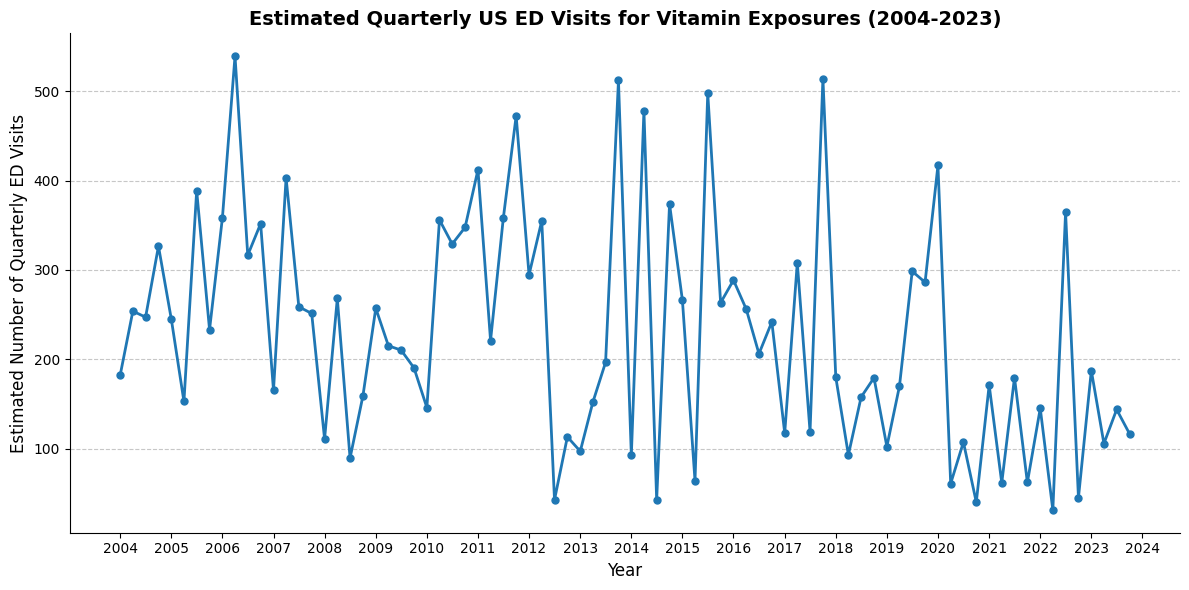

In [5]:
plt.figure(figsize=(12, 6))

plt.plot(quarterly_data.index, quarterly_data, 
         marker='o', linestyle='-', linewidth=2, color='#1f77b4', markersize=5)

plt.title('Estimated Quarterly US ED Visits for Vitamin Exposures (2004-2023)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Estimated Number of Quarterly ED Visits', fontsize=12)

# Format the X-axis to show a tick for every single year cleanly
plt.gca().xaxis.set_major_locator(mdates.YearLocator(1)) 
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

## 2.1 Ordinary Least Squares (OLS) Regression

**Objective:** To evaluate whether the absolute incidence of vitamin-related ED visits has significantly changed over the 2004-2023 period.

**Methodology:** We fit an OLS Linear Regression model to the annual estimates using Heteroscedasticity and Autocorrelation Consistent (HAC) standard errors.
* **Null Hypothesis ($H_0$):** The slope of the trend line is equal to zero (stationary trend).
* **Alternative Hypothesis ($H_1$):** The slope is not equal to zero (significant linear trend).

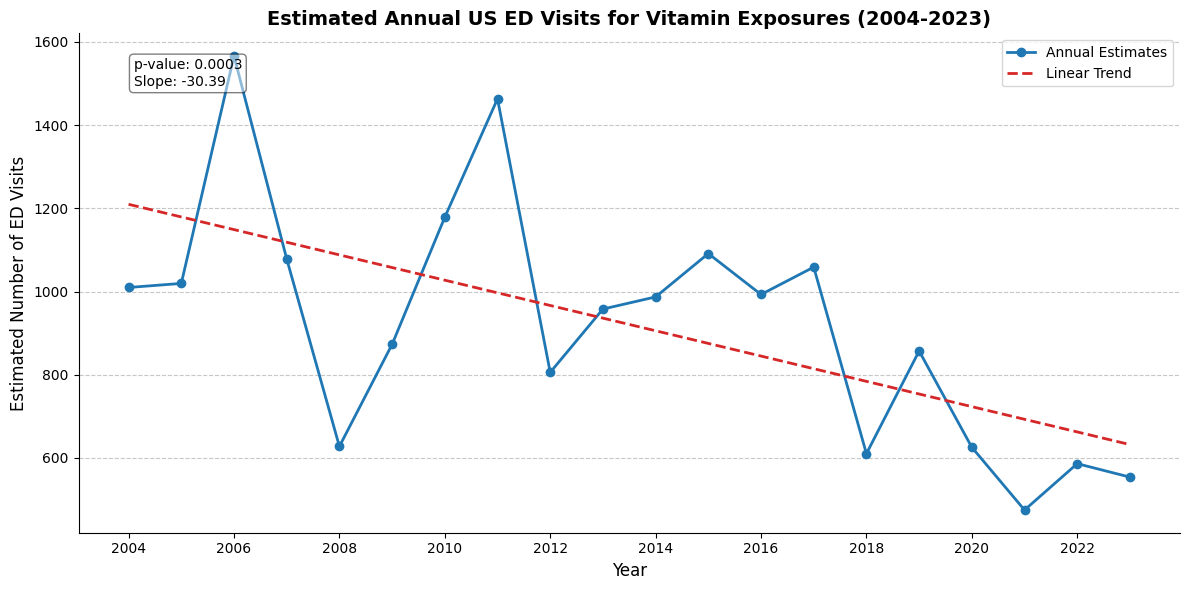

In [ ]:
# Prepare the data for regression: X (Year) and y (Estimated Visits)
X = yearly_data.index.values.reshape(-1, 1)
y = yearly_data.values 

# Add a constant term to the predictor to allow for an intercept in the model
X_with_const = sm.add_constant(X)

# Fit the Ordinary Least Squares (OLS) regression model
model = sm.OLS(y, X_with_const).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
# Extract the p-value and the slope (coefficient) for the 'Year' variable
# model.pvalues[1] refers to the p-value of the Year coefficient
p_value = model.pvalues[1]
slope = model.params[1]
intercept = model.params[0]

# Generate predicted values for the trend line based on the regression model
trend_line = intercept + slope * yearly_data.index


plt.figure(figsize=(12, 6))

# Plot the actual historical data points and connecting line
plt.plot(yearly_data.index, yearly_data, 
         marker='o', linestyle='-', linewidth=2, color='#1f77b4', 
         markersize=6, label='Annual Estimates')

# Plot the regression trend line to visualize the overall direction
plt.plot(yearly_data.index, trend_line, 
         linestyle='--', color='#d62728', linewidth=2, label='Linear Trend')

# Chart Title and Axis Labels
plt.title('Estimated Annual US ED Visits for Vitamin Exposures (2004-2023)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Estimated Number of ED Visits', fontsize=12)

# Set X-axis ticks every 2 years for better readability
plt.xticks(np.arange(min(yearly_data.index), max(yearly_data.index)+1, 2))

# Add a text box to display the statistical significance (p-value)
stats_text = f'p-value: {p_value:.4f}\nSlope: {slope:.2f}'
plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# Aesthetic cleanup: grid, spines, and layout
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend() # Add legend to distinguish data from trend line
plt.tight_layout()

plt.show()

## 2.2 Poisson Regression

**Objective:** To model the temporal trend using a statistical framework explicitly designed for count data.

**Methodology:** We fit a Generalized Linear Model (GLM) with a Poisson family and a log-link function. Unlike OLS, which models absolute linear changes, Poisson regression models relative (multiplicative) rates of change, yielding an Incidence Rate Ratio (IRR) that translates to an annual percentage change.

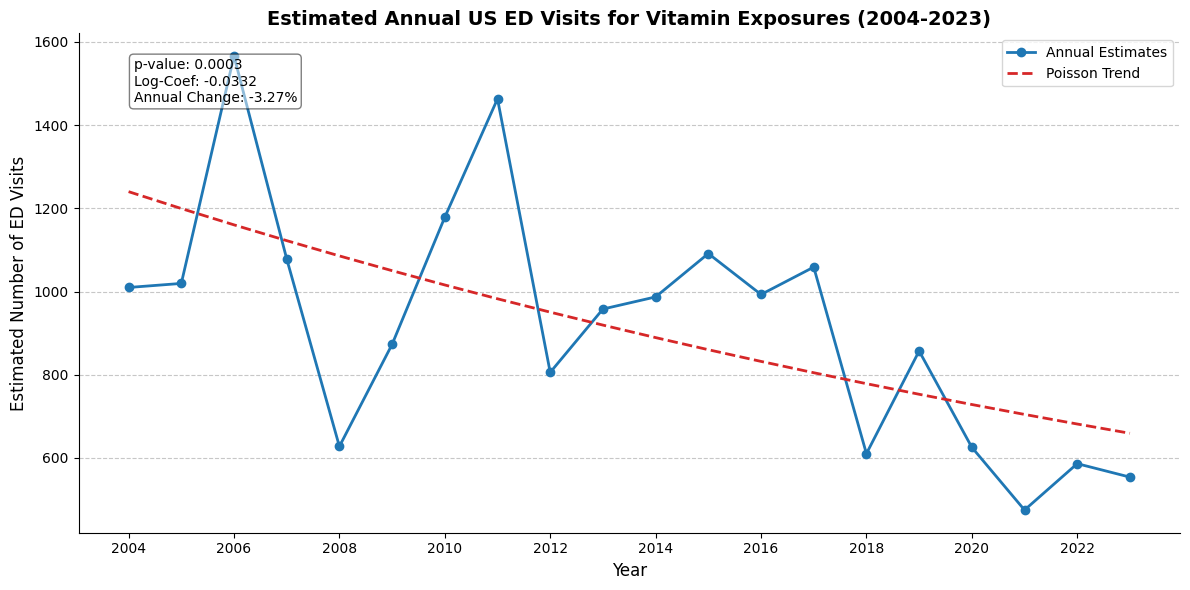

In [7]:
# Prepare the data for regression: X (Year) and y (Estimated Visits)
X = yearly_data.index.values.reshape(-1, 1)
y = yearly_data.values 

# Add a constant term to the predictor to allow for an intercept in the model
X_with_const = sm.add_constant(X)

# Fit the Poisson Regression using Generalized Linear Models (GLM)
model = sm.GLM(y, X_with_const, family=sm.families.Poisson()).fit(cov_type='HAC', cov_kwds={'maxlags': 1})

# Extract the p-value and the coefficient for the 'Year' variable
p_value = model.pvalues[1]
coef = model.params[1]  # This represents the log-rate of change

# Calculate the Incidence Rate Ratio (IRR) and annual percentage change
irr = np.exp(coef)
annual_pct_change = (irr - 1) * 100

# Generate predicted values for the trend line based on the Poisson model
# predict() automatically applies the exponential link function: exp(intercept + coef * X)
trend_line = model.predict(X_with_const)

plt.figure(figsize=(12, 6))

# Plot the actual historical data points and connecting line
plt.plot(yearly_data.index, yearly_data, 
         marker='o', linestyle='-', linewidth=2, color='#1f77b4', 
         markersize=6, label='Annual Estimates')

# Plot the regression trend line (note: it will have a slight curve due to the exponential link)
plt.plot(yearly_data.index, trend_line, 
         linestyle='--', color='#d62728', linewidth=2, label='Poisson Trend')

# Chart Title and Axis Labels
plt.title('Estimated Annual US ED Visits for Vitamin Exposures (2004-2023)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Estimated Number of ED Visits', fontsize=12)

# Set X-axis ticks every 2 years for better readability
plt.xticks(np.arange(min(yearly_data.index), max(yearly_data.index)+1, 2))

# Add a text box to display the statistical significance and interpretation
stats_text = (f'p-value: {p_value:.4f}\n'
              f'Log-Coef: {coef:.4f}\n'
              f'Annual Change: {annual_pct_change:.2f}%')

plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# Aesthetic cleanup: grid, spines, and layout
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend() # Add legend to distinguish data from trend line
plt.tight_layout()

plt.show()

## 2.3 Negative Binomial Regression

**Objective:** To account for potential overdispersion in the annual count data, which can cause Poisson models to underestimate standard errors.

**Methodology:** We fit a Negative Binomial regression model, which includes a parameter to model variance independently of the mean. We calculate the Incidence Rate Ratio (IRR) to derive the estimated annual percentage change in ED visits.

**Key Findings:** Annual vitamin-related ED visits demonstrate a consistent downward trajectory over the 20-year period. While the linear OLS model shows high statistical significance, count-based models (Poisson/Negative Binomial) highlight high inter-year variability. Nevertheless, the overall consensus across models confirms a secular decline in ED-treated vitamin exposures.

In [8]:
# Prepare the data for regression: X (Year) and y (Estimated Visits)
X = yearly_data.index.values.reshape(-1, 1)
y = yearly_data.values 

# Add a constant term to the predictor to allow for an intercept in the model
X_with_const = sm.add_constant(X)

# Fit the Negative Binomial Regression using Generalized Linear Models (GLM)
model_nb = sm.GLM(y, X_with_const, family=sm.families.NegativeBinomial()).fit(cov_type='HAC', cov_kwds={'maxlags': 1})

# Extract the p-value and the coefficient for the 'Year' variable
p_value = model_nb.pvalues[1]
coef = model_nb.params[1]

# Calculate the Incidence Rate Ratio (IRR) and annual percentage change
irr = np.exp(coef)
annual_pct_change = (irr - 1) * 100

print(model_nb.summary())
print(f'\nEstimated Annual Percentage Change: {annual_pct_change:.2f}%')

# Generate predicted values for the trend line
trend_line = model_nb.predict(X_with_const)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   20
Model:                            GLM   Df Residuals:                       18
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -156.12
Date:                Mon, 27 Apr 2026   Deviance:                       1.1437
Time:                        16:22:18   Pearson chi2:                     1.12
No. Iterations:                     5   Pseudo R-squ. (CS):            0.03951
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         80.6520     20.249      3.983      0.0

/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


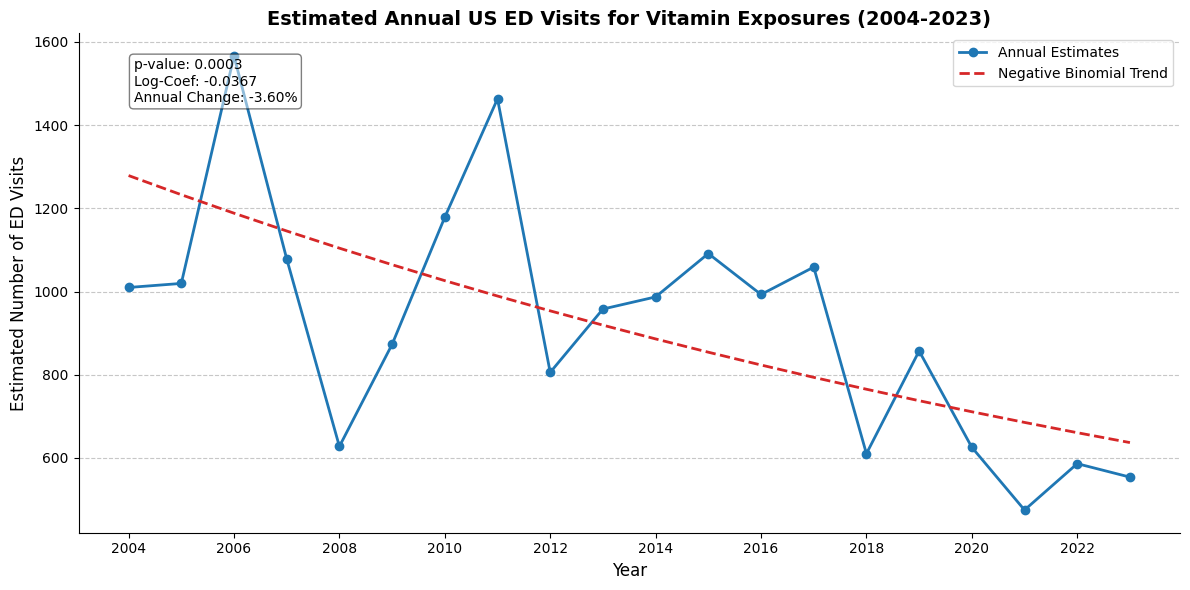

In [9]:
plt.figure(figsize=(12, 6))

# Plot the actual historical data points and connecting line (Consistent Style)
plt.plot(yearly_data.index, yearly_data, 
         marker='o', linestyle='-', linewidth=2, color='#1f77b4', 
         markersize=6, label='Annual Estimates')

# Plot the regression trend line
plt.plot(yearly_data.index, trend_line, 
         linestyle='--', color='#d62728', linewidth=2, label='Negative Binomial Trend')

# Chart Title and Axis Labels
plt.title('Estimated Annual US ED Visits for Vitamin Exposures (2004-2023)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Estimated Number of ED Visits', fontsize=12)

# Set X-axis ticks every 2 years for better readability
plt.xticks(np.arange(min(yearly_data.index), max(yearly_data.index)+1, 2))

# Add a text box to display the statistical significance and interpretation
stats_text = (f'p-value: {p_value:.4f}\n'
              f'Log-Coef: {coef:.4f}\n'
              f'Annual Change: {annual_pct_change:.2f}%')

plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# Aesthetic cleanup
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend()
plt.tight_layout()

plt.show()

# 3. Stratified Demographic & Clinical Analysis

## 3.1 Multivariate Interaction Models

**Objective:** To understand the underlying dynamics driving the global trend by identifying which specific demographic or clinical subpopulations are shifting over time.

**Methodology:** For each category (Age, Sex, Race, Disposition), we fit a Multivariate OLS Linear Regression incorporating interaction terms (`Year * Category`). 
* **Main Effect:** Captures absolute baseline differences in volume between subgroups.
* **Interaction Term:** Measures if the temporal slope for a specific subgroup diverges significantly ($p < 0.05$) from the baseline category over the study period.

--- Analyzing Category: AGE_GROUP ---


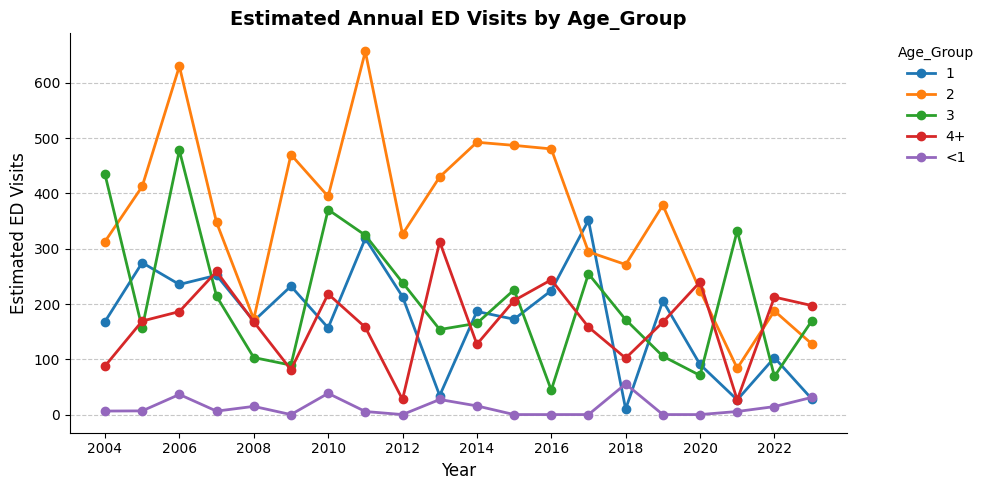

  > 1: Trend = -8.6 visits/year | p-value = 0.0000 (SIGNIFICANT)


  > 2: Trend = -13.3 visits/year | p-value = 0.0118 (SIGNIFICANT)


  > 3: Trend = -9.1 visits/year | p-value = 0.0091 (SIGNIFICANT)


  > 4+: Trend = +0.5 visits/year | p-value = 0.8024 (Not Significant)


  > <1: Trend = +0.1 visits/year | p-value = 0.8965 (Not Significant)


--- Analyzing Category: SEX ---


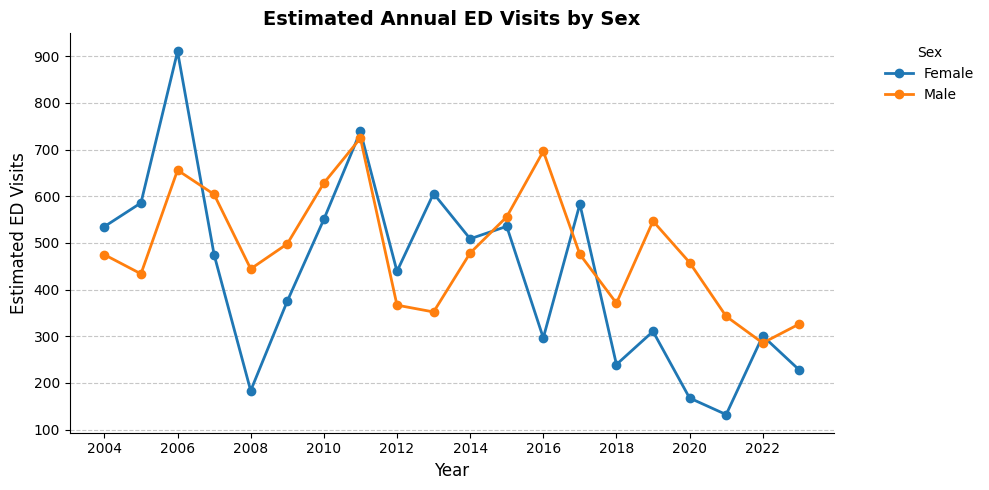

  > Female: Trend = -21.0 visits/year | p-value = 0.0004 (SIGNIFICANT)


  > Male: Trend = -9.4 visits/year | p-value = 0.0268 (SIGNIFICANT)


--- Analyzing Category: RACE ---


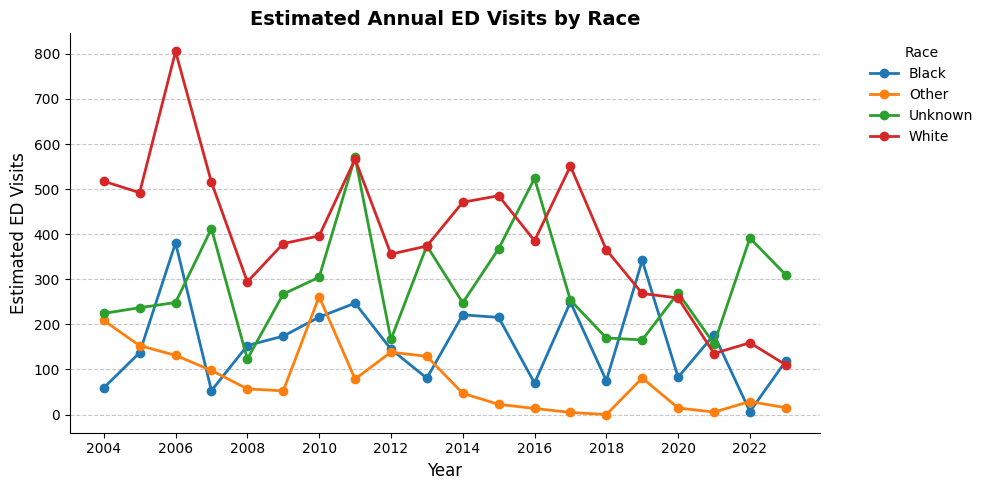

  > Black: Trend = -2.2 visits/year | p-value = 0.5271 (Not Significant)


  > Other: Trend = -8.7 visits/year | p-value = 0.0000 (SIGNIFICANT)


  > Unknown: Trend = +0.4 visits/year | p-value = 0.9123 (Not Significant)


  > White: Trend = -19.9 visits/year | p-value = 0.0000 (SIGNIFICANT)


--- Analyzing Category: DISPOSITION ---


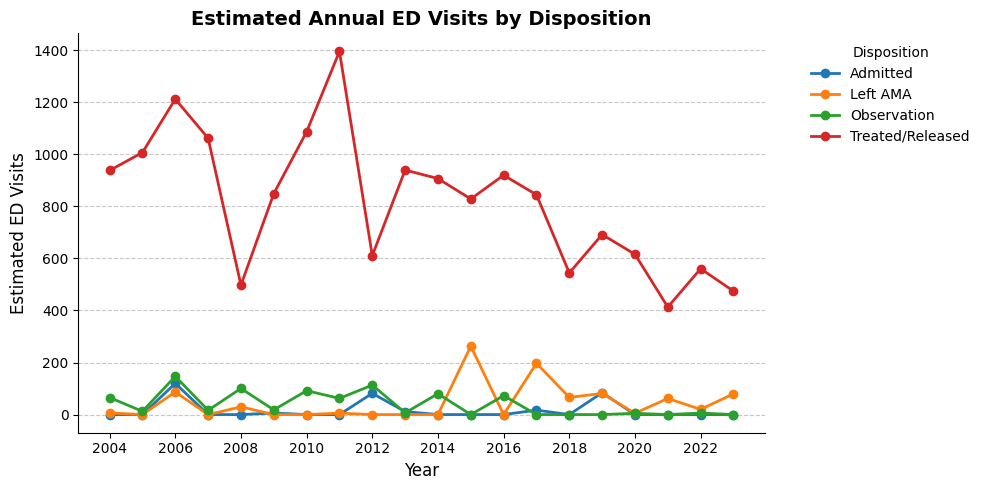

  > Admitted: Trend = -0.8 visits/year | p-value = 0.5108 (Not Significant)


  > Left AMA: Trend = +3.6 visits/year | p-value = 0.0136 (SIGNIFICANT)


  > Observation: Trend = -4.4 visits/year | p-value = 0.0000 (SIGNIFICANT)


  > Treated/Released: Trend = -28.8 visits/year | p-value = 0.0000 (SIGNIFICANT)


--- Analyzing Category: LOCATION ---


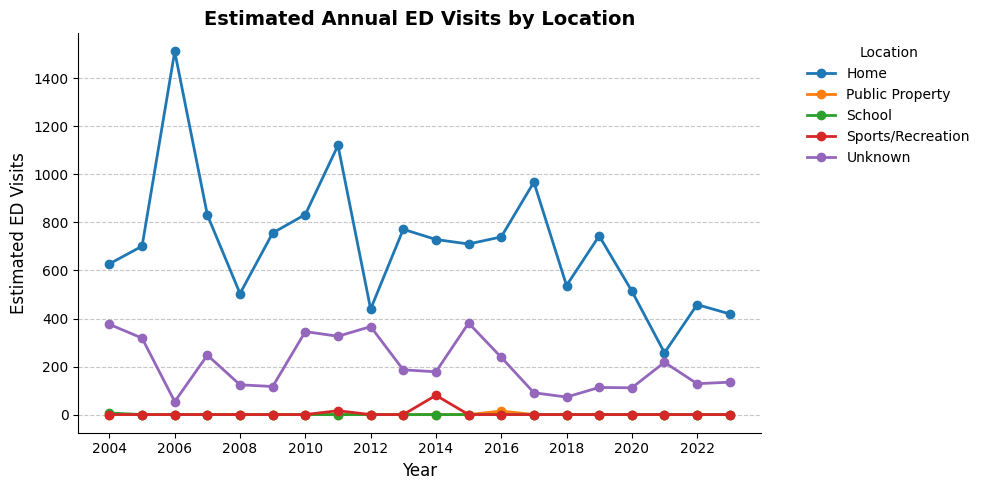

  > Home: Trend = -23.0 visits/year | p-value = 0.0199 (SIGNIFICANT)


  > Public Property: Trend = +0.1 visits/year | p-value = 0.3997 (Not Significant)


  > School: Trend = -0.1 visits/year | p-value = 0.2210 (Not Significant)


  > Sports/Recreation: Trend = -0.0 visits/year | p-value = 0.9990 (Not Significant)


  > Unknown: Trend = -7.4 visits/year | p-value = 0.0390 (SIGNIFICANT)


--- Analyzing Category: FIRE INVOLVEMENT ---


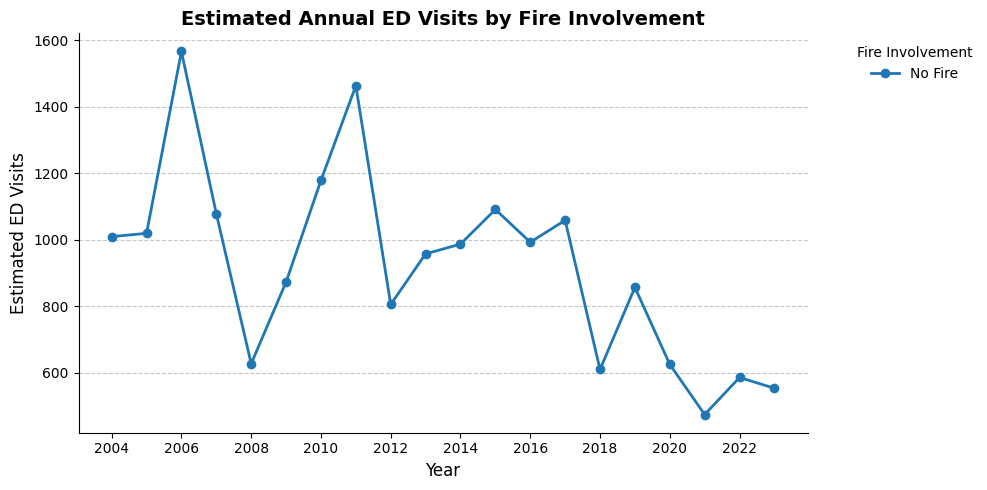

  > No Fire: Trend = -30.4 visits/year | p-value = 0.0003 (SIGNIFICANT)




In [10]:
categories_to_analyze = {
    'Age_Group': 'Age_Group',
    'Sex': 'Sex_Label',
    'Race': 'Race_Label',
    'Disposition': 'Disposition_Label',
    'Location': 'Location_Label',
    'Fire Involvement': 'Fire_Label'
}

for cat_name, col_name in categories_to_analyze.items():
    print(f"--- Analyzing Category: {cat_name.upper()} ---")
    
    # Group by Year and Subcategory
    yearly_cat_data = df.groupby(['Year', col_name])['Weight'].sum().unstack(fill_value=0)
    
    # PLOTTING
    plt.figure(figsize=(10, 5))
    for column in yearly_cat_data.columns:
        # Hide categories with 0 data to clean up the chart
        if yearly_cat_data[column].sum() > 0:
            plt.plot(yearly_cat_data.index, yearly_cat_data[column], marker='o', linewidth=2, label=str(column))

    plt.title(f'Estimated Annual ED Visits by {cat_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Estimated ED Visits', fontsize=12)
    plt.xticks(np.arange(min(yearly_cat_data.index), max(yearly_cat_data.index)+1, 2))
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.legend(title=cat_name, bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

    # REGRESSION ANALYSIS FOR EACH SUB-CATEGORY
    for column in yearly_cat_data.columns:
        if yearly_cat_data[column].sum() == 0:
            continue # Skip empty categories
            
        # Prepare OLS data
        X = yearly_cat_data.index.values
        y = yearly_cat_data[column].values
        X_sm = sm.add_constant(X) # Add intercept
        
        # Fit the model with HAC Robust Standard Errors
        model = sm.OLS(y, X_sm).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
        
        trend_coef = model.params[1] # Index 1 corresponds to the slope (Year)
        p_value = model.pvalues[1]
        
        # Interpretation of results
        significance = "SIGNIFICANT" if p_value < 0.05 else "Not Significant"
        print(f"  > {column}: Trend = {trend_coef:+.1f} visits/year | p-value = {p_value:.4f} ({significance})")
        print("\n")

In [11]:
# Dictionary of categories (Name to print : Column name in the df dataframe)
categories_to_analyze = {
    'Age': 'Age_Group',
    'Sex': 'Sex_Label',
    'Race': 'Race_Label',
    'Disposition': 'Disposition_Label'
}

for cat_name, col_name in categories_to_analyze.items():
    print(f"\n---> MODEL FOR: {cat_name.upper()} <---")
    
    # 1. Prepare the data: group by Year and by the specific Category
    # We obtain a "long" dataframe with columns: Year, [Category], Weight (which we'll rename to Visits)
    df_model = df.groupby(['Year', col_name])['Weight'].sum().reset_index()
    df_model = df_model.rename(columns={'Weight': 'Visits'})
    
    # Remove any categories with very few data points (e.g., Unknown) if they create noise
    # df_model = df_model[df_model[col_name] != 'Unknown']
    
    # 2. Define the formula
    # "Visits ~ Year * C(ColumnName)"
    # C() tells statsmodels to treat the variable as Categorical (creates dummies automatically)
    # The asterisk (*) creates the Main Effects AND the interaction terms automatically
    formula = f"Visits ~ Year * C({col_name})"
    
    # 3. Fit the interaction model with HAC Robust Standard Errors
    model = smf.ols(formula=formula, data=df_model).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
    
    # 4. Print the full results (Great to copy into the paper)
    print(model.summary().tables[1]) # Print only the coefficients table for a cleaner output
    
    # Automatic explanation for the interaction category
    print("\n  [INTERPRETATION]:")
    print(f"  The baseline category used by the model is indicated in the intercept.")
    print(f"  Look at the 'Year:C({col_name})[T.name]' rows: if the p-value (P>|t|) is < 0.05,")
    print(f"  it means the temporal trend for that category is significantly different from the baseline.")
    print("-" * 60)


---> MODEL FOR: AGE <---
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                1.755e+04   5060.543      3.469      0.001    7634.060    2.75e+04
C(Age_Group)[T.2]        9594.9311   9769.616      0.982      0.326   -9553.164    2.87e+04
C(Age_Group)[T.3]         898.5054   1.08e+04      0.083      0.934   -2.03e+04    2.21e+04
C(Age_Group)[T.4+]      -1.847e+04   7195.866     -2.567      0.010   -3.26e+04   -4369.001
C(Age_Group)[T.<1]      -1.872e+04   5020.513     -3.729      0.000   -2.86e+04   -8880.679
Year                       -8.6317      2.516     -3.430      0.001     -13.564      -3.700
Year:C(Age_Group)[T.2]     -4.6727      4.849     -0.964      0.335     -14.176       4.831
Year:C(Age_Group)[T.3]     -0.4284      5.377     -0.080      0.936     -10.967      10.110
Year:C(Age_Group)[T.4+]     9.1718      3.577      2.5

## 3.2 Clinical Severity Analysis

**Objective:** To evaluate whether the medical burden and acuity of vitamin-related incidents are intensifying, despite the overall decline in sheer volume.

**Methodology:** We calculate the "Admission Rate" by taking the ratio of severe clinical dispositions (hospital admissions and transfers) to total ED visits. This weighted time-series helps pinpoint if shifting market trends (e.g., higher potency supplements) are leading to more severe clinical outcomes.

**Key Findings:** Hospitalization rates for vitamin-related ED visits remained consistently low and actually declined over time, with most years showing a <5% admission rate. This confirms that these exposures are predominantly low-acuity, rarely require inpatient care, and are not increasing in severity.

Clinical Severity Analysis


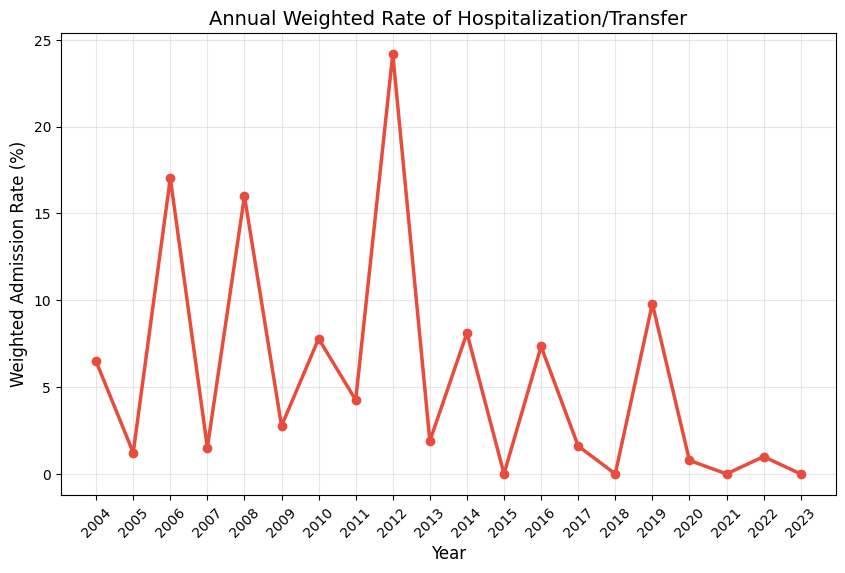

Average Weighted Admission Rate: 5.59%
Max Weighted Admission Rate: 24.18% in 2012


In [17]:
print('Clinical Severity Analysis')

# Define clinical severity (Admission = hospitalization)
# 4 = Treated and admitted as inpatient; 5 = Treated and transferred
df['is_admitted'] = df['Disposition'].astype(str).isin(['4', '5'])

# Calculate annual weighted rates
df['weighted_admitted'] = df['is_admitted'].astype(float) * df['Weight']
severity_annual = df.groupby('Year').agg({
    'Weight': 'sum',
    'weighted_admitted': 'sum'
}).rename(columns={'Weight': 'total_weighted_visits', 'weighted_admitted': 'total_weighted_admissions'})

severity_annual['admission_rate'] = (severity_annual['total_weighted_admissions'] / severity_annual['total_weighted_visits']) * 100

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(severity_annual.index, severity_annual['admission_rate'], marker='o', color='#e74c3c', linewidth=2.5)
plt.title('Annual Weighted Rate of Hospitalization/Transfer', fontsize=14)

plt.xticks(
    ticks=severity_annual.index,
    labels=severity_annual.index.astype(int),
    rotation=45
)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Weighted Admission Rate (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print(f'Average Weighted Admission Rate: {severity_annual["admission_rate"].mean():.2f}%')
print(f'Max Weighted Admission Rate: {severity_annual["admission_rate"].max():.2f}% in {severity_annual["admission_rate"].idxmax()}')

# 4. Narrative Deep-Dive: Topic Modeling (LDA)

**Objective:** To transform thousands of unstructured, free-text clinical narratives into interpretable epidemiological themes (e.g., a child finding a bottle vs. an adult confusing medications).

**Methodology:** We preprocess the narratives (tokenization, custom stop-word removal) and apply Count Vectorization. We then utilize Latent Dirichlet Allocation (LDA) to cluster the narratives into 5 distinct latent topics, allowing us to visualize the prevalence and defining keywords of each clinical scenario.

**Key Findings (Topic Extraction):** Topic modeling reveals that vitamin-related ED visits are largely driven by a consistent pattern of unintentional pediatric ingestions, commonly involving access to open or unsecured bottles. The themes heavily index on caregiver involvement (e.g., “mom”, “father”) and specific product types (gummies, chewables, multivitamins).

In [13]:
# Narratives
narratives_list = df['Narrative'].fillna('').astype(str).tolist()

# Custom stopwords for repeated non-informative terms
custom_stopwords = [
    'dx', 'pt', 'yo', 'yof', 'yom', 'yr', 'yrs',
    'ingestion', 'ingested', 'ingest', 'ingesting',
    'vitamin', 'vitamins', 'vit', 'vits',
    'poisoning', 'toxic', 'overdose',
    'unknown', 'possibly', 'accidental'
]

# Vectorize using counts, not TF-IDF, since LDA works better with count data
vectorizer = CountVectorizer(
    lowercase=True,
    stop_words='english',
    max_df=0.90,
    min_df=5,
    max_features=1500,
    ngram_range=(1, 2),
    token_pattern=r'\b[a-zA-Z][a-zA-Z]+\b'
)

X = vectorizer.fit_transform(narratives_list)

# Remove custom stopwords after vectorizer stopwords
feature_names = vectorizer.get_feature_names_out()
keep_indices = [
    i for i, word in enumerate(feature_names)
    if word not in custom_stopwords
    and not any(tok in custom_stopwords for tok in word.split())
]

X_filtered = X[:, keep_indices]
filtered_words = feature_names[keep_indices]

# Fit LDA
n_topics = 5
lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method='batch',
    max_iter=20
)

lda.fit(X_filtered)

# Display topics
for topic_idx, topic in enumerate(lda.components_):
    top_words = [filtered_words[i] for i in topic.argsort()[:-11:-1]]
    print(f'Topic {topic_idx + 1}: {", ".join(top_words)}')

Topic 1: bottle, got, pills, open, mouth, mom, sister, possible, open bottle, missing
Topic 2: home, control, poison, called, iron, poison control, oil, fish, fish oil, drug
Topic 3: multi, ate, took, children, childrens, tablets, bottle, od, mom, vitaminsdx
Topic 4: chewable, pills, non, male, old, acid, folic, folic acid, home, biotin
Topic 5: mom, bottle, multivitamins, patient, ate, multivitamin, gummy, substance, mother, child


**Key Findings (Topic Prevalence):** Topic distribution is relatively uniform across all identified themes, with no single anomaly dominating the dataset. This balanced prevalence suggests that vitamin-related ED visits represent a clinically homogeneous class of events—primarily low-complexity, household-driven pediatric exposures—rather than highly distinct, separable sub-epidemics.

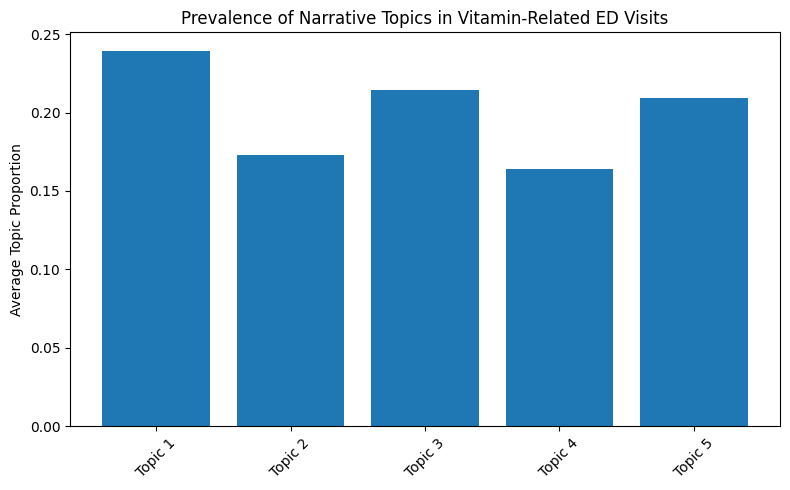

In [14]:
# Get topic distribution for each document
doc_topic_dist = lda.transform(X_filtered)

# Average prevalence of each topic
topic_prevalence = doc_topic_dist.mean(axis=0)

plt.figure(figsize=(8, 5))
plt.bar(
    [f'Topic {i+1}' for i in range(len(topic_prevalence))],
    topic_prevalence
)

plt.ylabel('Average Topic Proportion')
plt.title('Prevalence of Narrative Topics in Vitamin-Related ED Visits')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Key Findings (Word Importance):** The heatmap confirms that narrative topics are primarily defined by pediatric ingestion contexts and specific formulations (multivitamins, gummies). The significant overlap of word importance across topics further validates the clinical homogeneity of these low-risk exposure events.

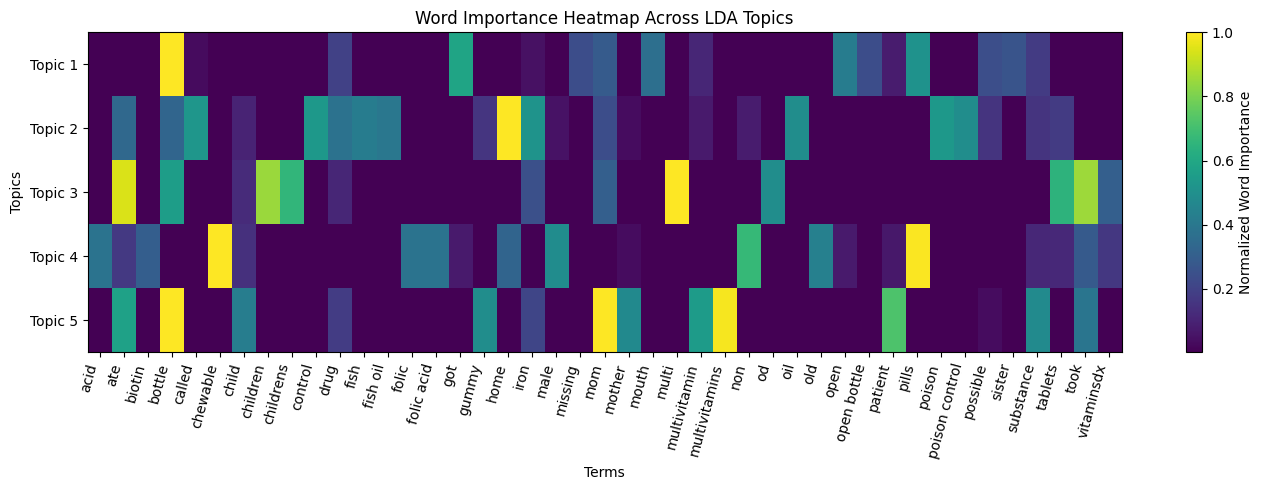

In [15]:
# Number of words to show per topic
top_n = 10

# Collect top words across all topics
top_words_all = set()
for topic in lda.components_:
    top_indices = topic.argsort()[-top_n:]
    top_words_all.update(filtered_words[top_indices])

top_words_all = sorted(list(top_words_all))

# Build topic-word importance matrix
heatmap_data = pd.DataFrame(
    index=[f'Topic {i+1}' for i in range(lda.n_components)],
    columns=top_words_all
)

for topic_idx, topic in enumerate(lda.components_):
    for word in top_words_all:
        word_idx = list(filtered_words).index(word)
        heatmap_data.loc[f'Topic {topic_idx+1}', word] = topic[word_idx]

heatmap_data = heatmap_data.astype(float)

# Normalize within each topic for readability
heatmap_data_norm = heatmap_data.div(heatmap_data.max(axis=1), axis=0)

plt.figure(figsize=(14, 5))
plt.imshow(heatmap_data_norm, aspect='auto')

plt.xticks(
    ticks=range(len(top_words_all)),
    labels=top_words_all,
    rotation=75,
    ha='right'
)

plt.yticks(
    ticks=range(lda.n_components),
    labels=[f'Topic {i+1}' for i in range(lda.n_components)]
)

plt.colorbar(label='Normalized Word Importance')
plt.title('Word Importance Heatmap Across LDA Topics')
plt.xlabel('Terms')
plt.ylabel('Topics')
plt.tight_layout()
plt.show()

# 5. Advanced Time-Series: Seasonality & SARIMA

**Objective:** To identify intrinsic seasonal cycles in the data and attempt to forecast future trends based on historical patterns.

**Methodology:** We aggregate the data into a monthly time-series and perform an additive seasonal decomposition (Trend, Seasonality, Residuals). We then fit a Seasonal Autoregressive Integrated Moving Average (SARIMA) model to predict the expected burden for the next 24 months.

**Key Findings:** Time-series decomposition reveals minimal and inconsistent seasonal patterns, indicating that vitamin-related ED visits are not driven by strong cyclical effects (e.g., school holidays or summer breaks). Consequently, SARIMA forecasting demonstrates high uncertainty bounds, suggesting that while the long-term secular decline is clear, short-term monthly volumes are subject to random variance rather than predictable seasonal cycles.

Seasonal ARIMA (SARIMA) Analysis


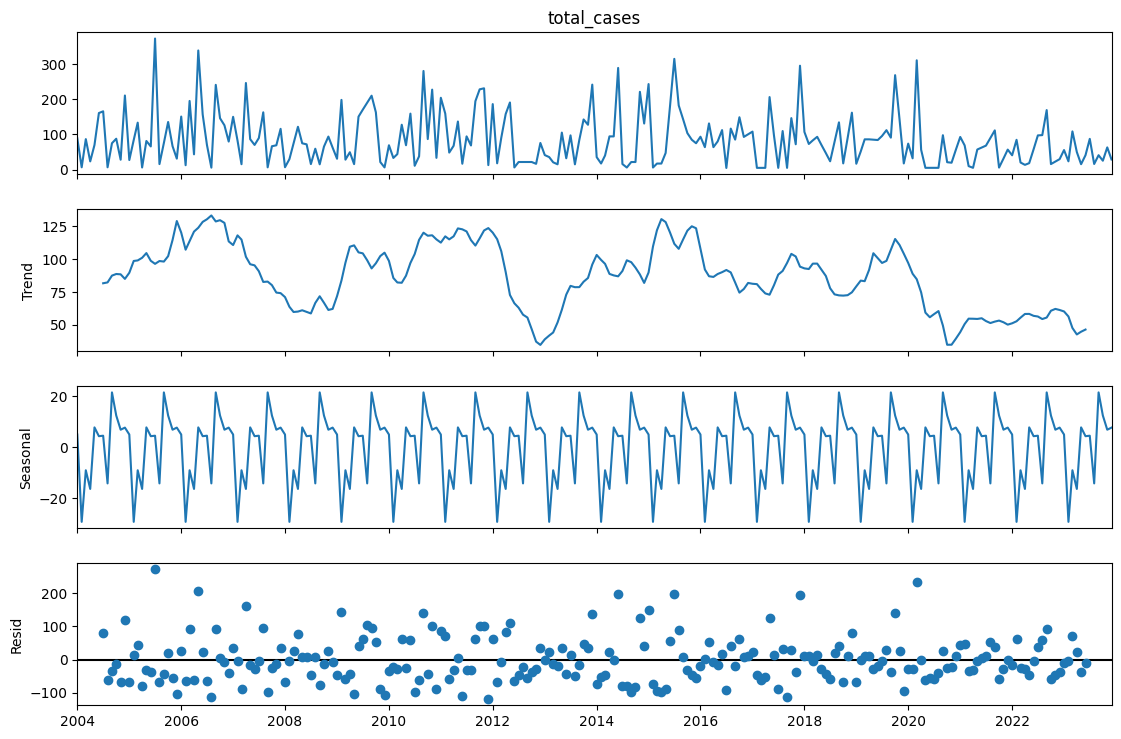

Fitting SARIMA model...
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0591      0.072      0.815      0.415      -0.083       0.201
ma.L1         -0.9816      0.057    -17.303      0.000      -1.093      -0.870
ar.S.L12       0.0086      0.030      0.283      0.777      -0.051       0.068
ma.S.L12      -1.0000      0.099    -10.119      0.000      -1.194      -0.806
sigma2      5385.3988   1.83e-05   2.93e+08      0.000    5385.399    5385.399


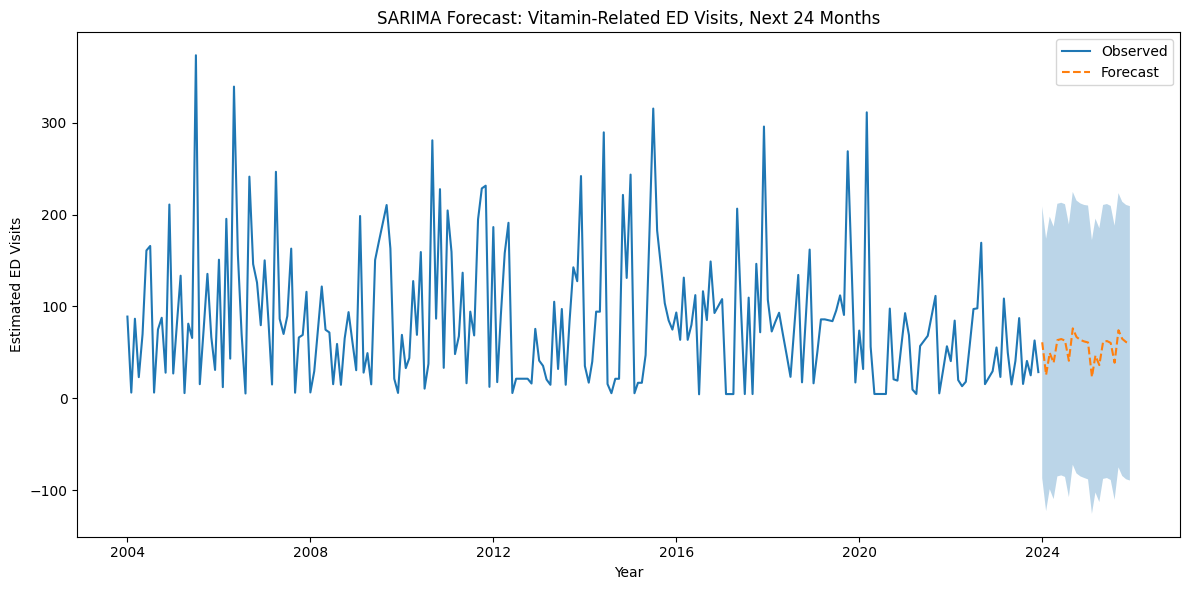

In [16]:
print('Seasonal ARIMA (SARIMA) Analysis')

# 1. Prepare monthly time-series data
ts_data = monthly_yearly_data.copy()

ts_data['date'] = pd.to_datetime(
    ts_data[['Year', 'Month']].assign(day=1)
)

ts_data = (
    ts_data
    .set_index('date')
    .sort_index()
    .rename(columns={'Weight': 'total_cases'})
)

# Keep only needed column
ts_data = ts_data[['total_cases']]

# Force proper monthly frequency
ts_data = ts_data.asfreq('MS')

# Fill missing months if any
ts_data['total_cases'] = ts_data['total_cases'].interpolate()

# 2. Decomposition
decomposition = seasonal_decompose(
    ts_data['total_cases'],
    model='additive',
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

# 3. Fit SARIMA
print('Fitting SARIMA model...')

model_sarima = SARIMAX(
    ts_data['total_cases'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model_sarima.fit(disp=False)

print(results.summary().tables[1])

# 4. Forecast next 24 months
forecast = results.get_forecast(steps=24)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Explicitly create correct future dates
future_index = pd.date_range(
    start=ts_data.index[-1] + pd.DateOffset(months=1),
    periods=24,
    freq='MS'
)

forecast_mean.index = future_index
forecast_ci.index = future_index

# 5. Plot
plt.figure(figsize=(12, 6))

plt.plot(
    ts_data.index,
    ts_data['total_cases'],
    label='Observed'
)

plt.plot(
    forecast_mean.index,
    forecast_mean,
    label='Forecast',
    linestyle='--'
)

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.3
)

plt.title('SARIMA Forecast: Vitamin-Related ED Visits, Next 24 Months')
plt.xlabel('Year')
plt.ylabel('Estimated ED Visits')
plt.legend()
plt.tight_layout()
plt.show()